# Deep Learning Comparison

Trains the four PyTorch configurations from Section VI-B (MLP, LSTM, CNN,
and an LSTM given XGBoost's engineered features) and compares them against
XGBoost's own 5-seed mean, not the single seed-42 run, so this table
uses the same basis on every row, matching the paper's Table IV exactly
(fixing what the paper's own review process caught as issues m14/m15 in an
earlier draft: comparing a 5-seed mean against a single-seed number).

Requires the `torch` extra: `uv sync --extra torch`.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import matplotlib.pyplot as plt
import pandas as pd

from evloadshaping.config import SEEDS
from evloadshaping.data import load_raw_data
from evloadshaping.features import build_features, split_data
from evloadshaping.models import compute_baselines, evaluate_xgboost_seeds
from evloadshaping.torch_models import run_torch_comparison

DATA_PATH = Path('../data/20260514_uma_adabyron_data.csv')
print(f'Seeds used for every multi-seed row below: {SEEDS}')


Seeds used for every multi-seed row below: (42, 43, 44, 45, 46)


In [2]:
raw_frame, charger_ids = load_raw_data(DATA_PATH)
feature_frame = build_features(raw_frame, charger_ids)
x_train, x_test, y_pv_train, y_pv_test, y_ev_train, y_ev_test = split_data(feature_frame)
print(f'Train: {len(x_train):,} rows | Test: {len(x_test):,} rows')


Train: 46,144 rows | Test: 11,537 rows


In [3]:
baselines = compute_baselines(x_test, y_pv_test, y_ev_test, x_train, y_pv_train, y_ev_train)
xgb_pv_seeds = evaluate_xgboost_seeds(x_train, y_pv_train, x_test, y_pv_test)
xgb_ev_seeds = evaluate_xgboost_seeds(x_train, y_ev_train, x_test, y_ev_test)


In [4]:
# This is the slow cell: 4 architectures x 2 targets x 5 seeds each.
torch_results = run_torch_comparison(x_train, x_test, y_pv_train, y_pv_test, y_ev_train, y_ev_test)
torch_results


{'mlp': {'pv': {'mae': 486.90174971230283,
   'mae_std': 17.05954932023363,
   'rmse': 967.3516167345497,
   'rmse_std': 16.95290879311183},
  'ev': {'mae': 80.8742160158765,
   'mae_std': 5.429951759243831,
   'rmse': 285.0335879915465,
   'rmse_std': 10.049958971972336}},
 'lstm': {'pv': {'mae': 505.91494140625,
   'mae_std': 12.26612075511449,
   'rmse': 989.1432795182072,
   'rmse_std': 17.53648282744665},
  'ev': {'mae': 75.55236358642578,
   'mae_std': 3.6352394975595406,
   'rmse': 275.4638600852654,
   'rmse_std': 6.516437094505445}},
 'cnn': {'pv': {'mae': 534.5875183105469,
   'mae_std': 27.558459267419938,
   'rmse': 1016.4900636986437,
   'rmse_std': 28.705408939947922},
  'ev': {'mae': 95.30779418945312,
   'mae_std': 3.722843415240668,
   'rmse': 303.87854530454007,
   'rmse_std': 12.844473086535546}},
 'lstm_features': {'pv': {'mae': 511.83368530273435,
   'mae_std': 14.401856002484273,
   'rmse': 1002.5004787717602,
   'rmse_std': 9.672936626961137},
  'ev': {'mae': 76.

In [5]:
rows = [
    {'model': 'persistence', 'target': 'pv', **baselines['persistence']['pv']},
    {'model': 'ridge_regression', 'target': 'pv', **baselines['ridge_regression']['pv']},
    {'model': 'xgboost', 'target': 'pv', **xgb_pv_seeds},
]
for model_name in ('mlp', 'lstm', 'cnn', 'lstm_features'):
    rows.append({'model': model_name, 'target': 'pv', **torch_results[model_name]['pv']})
rows += [
    {'model': 'persistence', 'target': 'ev', **baselines['persistence']['ev']},
    {'model': 'ridge_regression', 'target': 'ev', **baselines['ridge_regression']['ev']},
    {'model': 'xgboost', 'target': 'ev', **xgb_ev_seeds},
]
for model_name in ('mlp', 'lstm', 'cnn', 'lstm_features'):
    rows.append({'model': model_name, 'target': 'ev', **torch_results[model_name]['ev']})

comparison = pd.DataFrame(rows)
comparison.round(2)


,model,target,mae,rmse,mae_std,rmse_std
0,persistence,pv,465.35,1024.03,NaN,NaN
1,ridge_regression,pv,503.99,977.85,NaN,NaN
2,xgboost,pv,451.01,960.50,2.58,3.43
3,mlp,pv,486.90,967.35,17.06,16.95
4,lstm,pv,505.91,989.14,12.27,17.54
5,cnn,pv,534.59,1016.49,27.56,28.71
6,lstm_features,pv,511.83,1002.50,14.40,9.67
7,persistence,ev,52.29,273.24,NaN,NaN
8,ridge_regression,ev,64.41,265.35,NaN,NaN
9,xgboost,ev,65.40,300.96,0.76,7.69


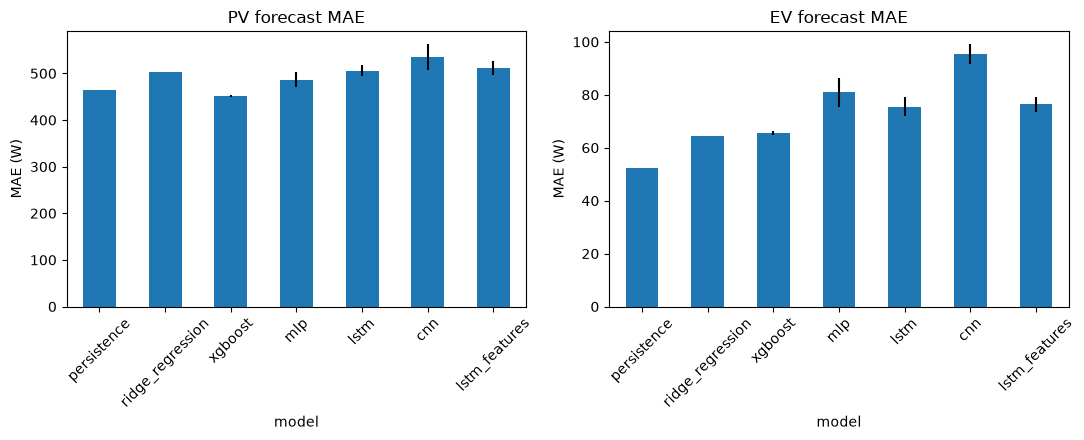

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for target, ax in zip(['pv', 'ev'], axes):
    subset = comparison[comparison['target'] == target].set_index('model')
    subset['mae'].plot.bar(ax=ax, color='tab:blue', yerr=subset['mae_std'] if 'mae_std' in subset else None)
    ax.set_title(f'{target.upper()} forecast MAE')
    ax.set_ylabel('MAE (W)')
    ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()


In [7]:
print('None of the four PyTorch configurations beats XGBoost\'s 5-seed-mean MAE on either target:')
for target in ('pv', 'ev'):
    xgb_mae = comparison[(comparison['model'] == 'xgboost') & (comparison['target'] == target)]['mae'].iloc[0]
    dl_maes = comparison[comparison['model'].isin(['mlp', 'lstm', 'cnn', 'lstm_features']) & (comparison['target'] == target)]['mae']
    print(f'  {target.upper()}: XGBoost {xgb_mae:.1f} W vs. DL range {dl_maes.min():.1f}-{dl_maes.max():.1f} W')


None of the four PyTorch configurations beats XGBoost's 5-seed-mean MAE on either target:
  PV: XGBoost 451.0 W vs. DL range 486.9-534.6 W
  EV: XGBoost 65.4 W vs. DL range 75.6-95.3 W
